In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


# **Exercise 1**

Use the boston Housing dataset, analyze it, and identify its leverage points. This dataset is available in the seaborn website

Predecir MEDV

## Preparar datos

In [34]:
boston_house_df = pd.read_csv("/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/Parte_2/bostonHousing_leveragePoints/HousingData.csv")

In [35]:
print("Tamaño del DataFrame:")
print(boston_house_df.shape)

print("\nPrevisualización del DataFrame:")
display(boston_house_df.head(10))

Tamaño del DataFrame:
(506, 14)

Previsualización del DataFrame:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,NaN,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [36]:
boston_house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [50]:
boston_house_df.isnull().sum()

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [64]:
boston_house_df['LSTAT'].isnull().sum()

np.int64(0)

In [38]:
#Rellenamos datos faltantes con la mediana
boston_house_df[['CRIM','ZN','INDUS','CHAS','AGE']] = boston_house_df[['CRIM','ZN','INDUS','CHAS','AGE']].fillna(boston_house_df[['CRIM','ZN','INDUS','CHAS','AGE']].median())

In [63]:
boston_house_df['LSTAT'] = boston_house_df['LSTAT'].fillna(boston_house_df['LSTAT'].median())

## Inicio

In [65]:
#Hat matrix
y = boston_house_df["MEDV"].values.reshape(-1,1)
X = boston_house_df[['CRIM','ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']].values

In [66]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ X.T @ y
y_hat = X @ beta

print("Beta:\n", beta)
print("\ny hat (vector):\n", y_hat)

Beta:
 [[-0.09451075]
 [ 0.04438412]
 [-0.0462769 ]
 [ 3.14340957]
 [-2.86867502]
 [ 6.03482974]
 [-0.0139184 ]
 [-0.97995322]
 [ 0.14607433]
 [-0.00820094]
 [-0.40544326]
 [ 0.014517  ]
 [-0.37717411]]

y hat (vector):
 [[29.31037183]
 [24.51384411]
 [31.24047897]
 [29.89158438]
 [27.50113817]
 [25.420903  ]
 [21.65626631]
 [19.30800943]
 [11.63859352]
 [18.43025737]
 [19.62044139]
 [20.4577351 ]
 [20.09384629]
 [20.64699473]
 [20.45867343]
 [20.13390472]
 [21.66723537]
 [18.47840376]
 [16.0387227 ]
 [18.85830947]
 [13.57926108]
 [18.85814442]
 [18.10930677]
 [15.44367893]
 [17.2671102 ]
 [13.96132846]
 [16.68946797]
 [16.36461686]
 [21.8800246 ]
 [23.44612595]
 [13.24895774]
 [19.21520444]
 [11.28215434]
 [15.18156633]
 [15.16802695]
 [21.95762544]
 [21.03084659]
 [22.26773447]
 [22.63790977]
 [31.23128627]
 [34.78561759]
 [28.63167921]
 [24.55644607]
 [24.35581249]
 [22.16662746]
 [20.38098562]
 [19.5279001 ]
 [17.74989914]
 [ 9.28539614]
 [16.27435005]
 [20.52423694]
 [22.51076623]

In [67]:
resid = y- y_hat

#Hat matrix
H = X @ XtX_inv @ X.T
leverage = np.diag(H)
print(leverage)

[0.01553804 0.01004738 0.0109236  0.01415541 0.01414964 0.01390553
 0.01151848 0.02900839 0.05194016 0.02732682 0.03406678 0.0211054
 0.01550304 0.01257201 0.01271379 0.01337906 0.02163159 0.00962483
 0.0233431  0.01200285 0.01708853 0.01168445 0.01176405 0.01588775
 0.01291311 0.01536202 0.01345404 0.01373411 0.01169225 0.00945079
 0.01682267 0.0158184  0.03021594 0.01472722 0.02086891 0.00789355
 0.00647302 0.01057099 0.01457868 0.03136575 0.03287918 0.02568963
 0.02135961 0.02186293 0.00949097 0.00952815 0.0123507  0.02298237
 0.04924585 0.01409618 0.01150776 0.01792857 0.01225236 0.01212709
 0.04737379 0.0326405  0.03029539 0.03954034 0.01767367 0.01354964
 0.01912345 0.02860017 0.01889589 0.01548419 0.02877993 0.02398421
 0.02522429 0.01329585 0.01181974 0.01080729 0.0243193  0.01767025
 0.02240398 0.02676964 0.01578494 0.01290134 0.01315452 0.01246052
 0.01331342 0.01425368 0.00746861 0.00941447 0.00745483 0.00615528
 0.00736859 0.00764821 0.0090905  0.00809094 0.01607642 0.01250

In [69]:
print("H:", H.shape)
print("\ny:", y.shape)
print("\nx:", X.shape)
print("\nbeta:\n", beta)

H: (506, 506)

y: (506, 1)

x: (506, 13)

beta:
 [[-0.09451075]
 [ 0.04438412]
 [-0.0462769 ]
 [ 3.14340957]
 [-2.86867502]
 [ 6.03482974]
 [-0.0139184 ]
 [-0.97995322]
 [ 0.14607433]
 [-0.00820094]
 [-0.40544326]
 [ 0.014517  ]
 [-0.37717411]]


In [77]:
summary = pd.DataFrame(
    {
        "index": np.arange(len(boston_house_df)),
        "leverage": leverage,
        "y": y.flatten(),
        "y_hat": y_hat.flatten(),
        "resid": resid.flatten(),
    }
)

In [78]:
print("Top Ten Leverage Points")

print(summary.sort_values(by="leverage", ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage     y   y_hat  resid
380    380     0.287  10.4  17.336 -6.936
418    418     0.187   8.8   5.371  3.429
405    405     0.150   5.0   9.038 -4.038
410    410     0.110  15.0  10.661  4.339
155    155     0.089  15.6  20.829 -5.229
490    490     0.082   8.1   4.567  3.533
489    489     0.075   7.0   9.094 -2.094
355    355     0.075  20.6  15.381  5.219
492    492     0.075  20.1  17.166  2.934
488    488     0.074  15.2  12.322  2.878


In [79]:
n, p = X.shape
print("n", n)
print("p", p)

avg_lev = p/n
treshold = 2*avg_lev

print("avg_lev:", avg_lev)
print("treshold:", treshold)

n 506
p 13
avg_lev: 0.025691699604743084
treshold: 0.05138339920948617


<function matplotlib.pyplot.show(close=None, block=None)>

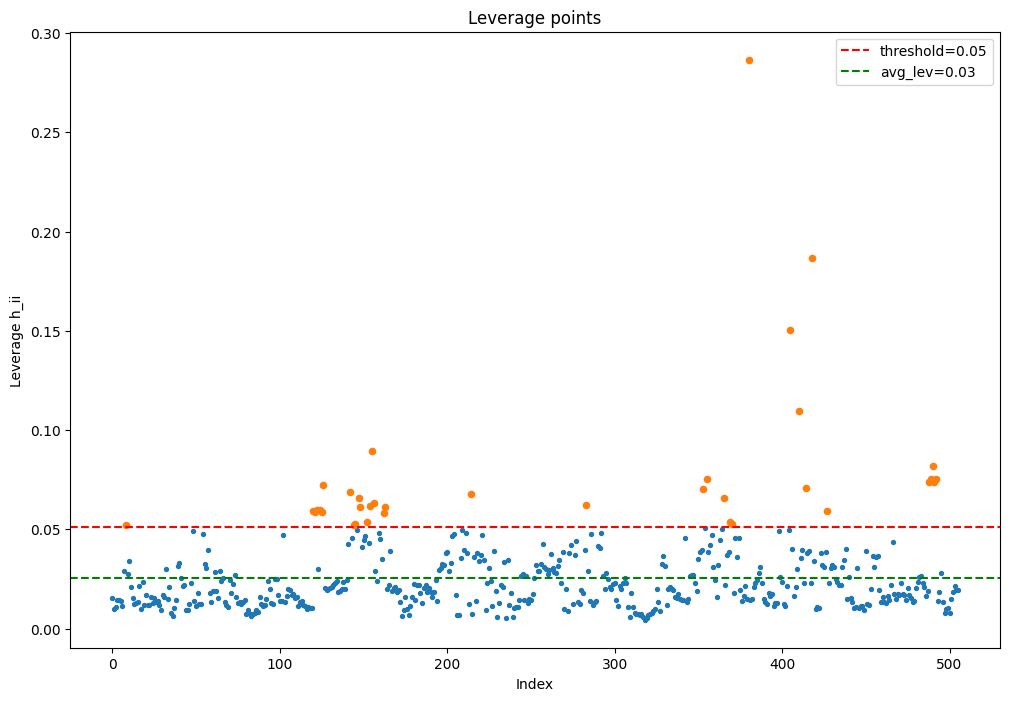

In [80]:
#Plotting leverage points
#Plotting leverage points
plt.figure(figsize=(12, 8))
plt.scatter(summary["index"], summary["leverage"], s=8)
plt.axhline(treshold, color="r", linestyle="--", label=f"threshold={treshold:.2f}")
plt.axhline(avg_lev, color='g', linestyle="--", label=f"avg_lev={avg_lev:.2f}")
hi_idx = summary.index[summary["leverage"]>treshold].tolist()
if len(hi_idx) > 0:
    plt.scatter(hi_idx, summary.loc[hi_idx, "leverage"], s=20)
plt.title("Leverage points")
plt.xlabel("Index")
plt.ylabel("Leverage h_ii")
plt.legend()
plt.show

leverage points

In [106]:
houses_medv = boston_house_df['MEDV'].values.reshape(-1,1)
houses_age = boston_house_df['AGE'].values.reshape(-1,1)

In [107]:
X = sm.add_constant(houses_age)
model = sm.OLS(houses_medv, X).fit()

In [108]:
#Printing model parameter
print("Model with mansions:")
print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions:
Intercept: 31.23
Slope: -0.13


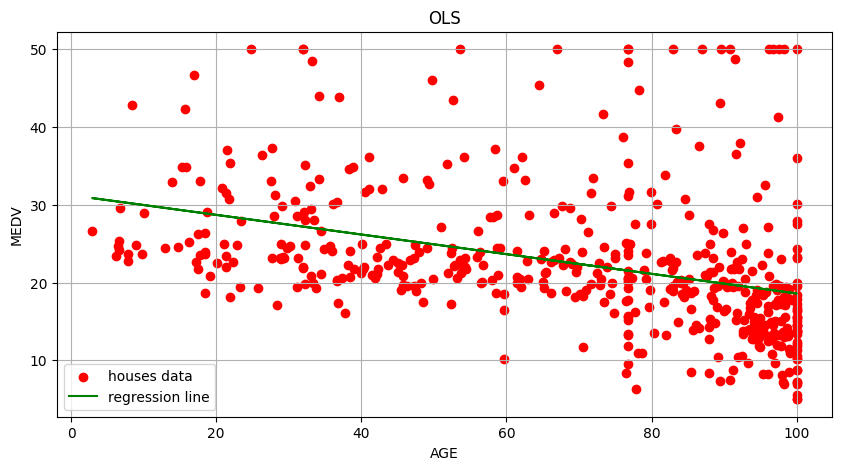

In [116]:
plt.figure(figsize=(10, 5))
plt.scatter(houses_age, houses_medv, label="houses data", color="r")
plt.plot(houses_age, model.params[0] + model.params[1] * houses_age, color='g', label='regression line')
plt.title('OLS')
plt.xlabel("AGE")
plt.ylabel("MEDV")
plt.legend()
plt.grid(True)
plt.show()

In [117]:
#Get the leverage points
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

#Threshold
n = len(houses_age)
p = X.shape[1]
avg_lev = p/n
threshold = 2 * avg_lev
print(threshold)

0.007905138339920948


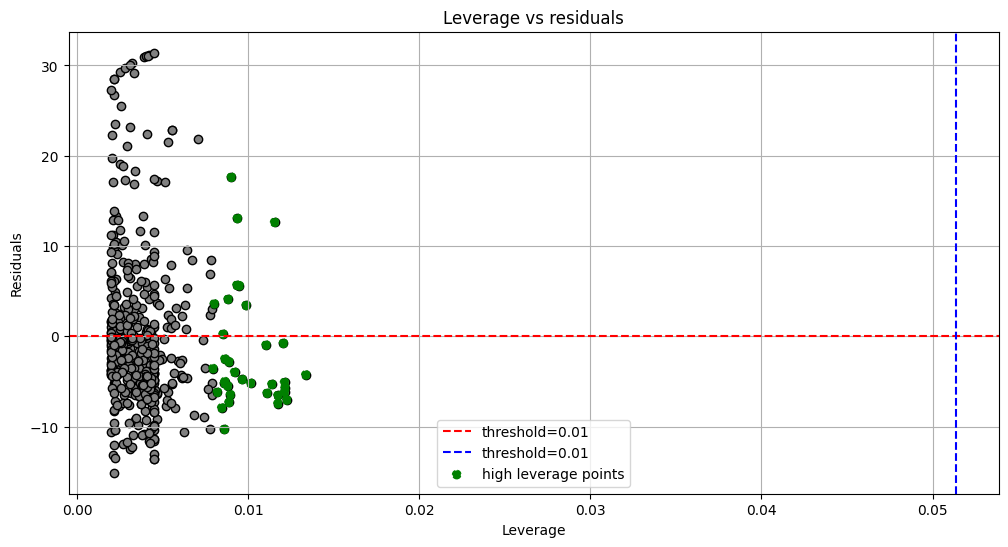

In [119]:
plt.figure(figsize=(12, 6))
plt.scatter(leverage, residuals, edgecolors='black', facecolors='grey')
plt.axhline(0, color='r', linestyle="--", label=f"threshold={threshold:.2f}")
plt.axvline(treshold, color='b', linestyle="--", label=f"threshold={threshold:.2f}")

high_leverage_points = np.where(leverage>threshold)
plt.scatter(leverage[high_leverage_points], residuals[high_leverage_points], color='green', linestyle="--", label="high leverage points")


plt.legend()
plt.title("Leverage vs residuals")
plt.xlabel("Leverage")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

In [120]:
print(f"High leverage points (index): {high_leverage_points}")
print(f"Leverage values: {leverage[high_leverage_points]}")

High leverage points (index): (array([ 40,  41,  42,  43,  52,  65,  70,  71,  72,  73, 194, 199, 200,
       202, 214, 228, 238, 243, 249, 250, 251, 252, 253, 255, 271, 284,
       293, 298, 299, 302, 303, 325, 329, 352]),)
Leverage values: [0.00935122 0.01337432 0.01213119 0.01216385 0.00795113 0.00880558
 0.01213119 0.00888609 0.01174342 0.01226212 0.00854063 0.0094909
 0.00988899 0.00937905 0.01111392 0.00902132 0.00861956 0.01174342
 0.00888609 0.01015033 0.0113946  0.01206604 0.01155237 0.00846216
 0.00921284 0.00802644 0.00864598 0.00820402 0.01105212 0.00864598
 0.00883237 0.00966025 0.00896707 0.00861956]


# **Exercise 2**

Use the diamonds dataset, analyze it, and identify its leverage points. This dataset is available in the seaborn website
